In [ ]:
# =====================================================================
# CELL 1 (MỚI): GIẢI NÉN DỮ LIỆU SIÊU TỐC TỪ GOOGLE DRIVE
# (Chạy cell này làm Bước 1 kể từ ngày hôm sau - THAY THẾ HOÀN TOÀN CELL 1 CŨ)
# =====================================================================
import os
import zipfile
from google.colab import drive

# 1. Định nghĩa lại các biến môi trường cấu hình
TARGET_CLASSES = ["Bowling", "BoxingPunchingBag", "Biking", "JumpRope", "PlayingGuitar"]
DATASET_DIR = "selected_dataset"

# 2. Kết nối Google Drive để lấy hàng
print("👉 Vui lòng kết nối Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

ZIP_SOURCE_PATH = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Data/ucf5_selected_dataset.zip"

# 3. Kiểm tra và giải nén cục bộ vào ổ đĩa Colab
if os.path.exists(ZIP_SOURCE_PATH):
    print("⏳ Phát hiện file dữ liệu sạch trên Drive. Đang giải nén siêu tốc vào Colab...")

    with zipfile.ZipFile(ZIP_SOURCE_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print(f"✅ Đã giải nén xong! Thư mục nguồn '{DATASET_DIR}' đã sẵn sàng hoạt động.")

    # Kiểm tra xem có bao nhiêu video được khôi phục
    total_videos = sum([len(files) for r, d, files in os.walk(DATASET_DIR) if any(f.endswith(('.avi', '.mp4')) for f in files)])
    print(f"📊 Tổng số video vật lý đã khôi phục thành công: {total_videos} video.")
else:
    print(f"❌ LỖI: Không tìm thấy file lưu trữ tại {ZIP_SOURCE_PATH}!")
    print("⚠️ Vui lòng kiểm tra lại xem bạn đã chạy CELL BACKUP ở Bước 1 ngày hôm trước chưa.")
# ==========================================
# CELL 2: PHÂN TÍCH VÀ TRÍCH XUẤT FRAME (Cập nhật kích thước & Chuẩn hóa)
# ==========================================
import cv2
import numpy as np

# Cấu hình tối ưu cho CNN truyền thống tự xây dựng (Tránh nổ tham số)
IMAGE_HEIGHT, IMAGE_WIDTH = 128, 128
SEQUENCE_LENGTH = 30

def extract_frames_from_video(video_path):
    """
    Trích xuất phân phối đều các khung hình từ video và chuẩn hóa pixel về [0, 1].
    """
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count < SEQUENCE_LENGTH:
        sampled_indices = np.arange(video_frames_count)
    else:
        sampled_indices = np.linspace(0, video_frames_count - 1, num=SEQUENCE_LENGTH).astype(int)

    for frame_index in sampled_indices:
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        success, frame = video_reader.read()

        if not success:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized_frame = cv2.resize(frame_rgb, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Chuẩn hóa Min-Max [0, 1] phù hợp cho mạng CNN huấn luyện từ đầu (Scratch)
        normalized_frame = resized_frame.astype(np.float32) / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()

    # Padding bằng khung hình rỗng nếu video quá ngắn
    while len(frames_list) < SEQUENCE_LENGTH:
        frames_list.append(np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.float32))

    return np.array(frames_list, dtype=np.float32)

⏳ Đang tải dataset UCF101 qua kagglehub (Tự động tối ưu tốc độ)...


100%|██████████| 6.49G/6.49G [06:05<00:00, 19.1MB/s]

Extracting files...


✅ Đã tải xong! Dữ liệu gốc nằm tại cache: /root/.cache/kagglehub/datasets/pevogam/ucf101/versions/1
📦 Đang tiến hành lọc và trích xuất thông minh 5 classes...
🔍 Phát hiện thư mục thô. Tiến hành copy chọn lọc các class...
 -> Đang copy dữ liệu cho lớp: [ Bowling ]
 -> Đang copy dữ liệu cho lớp: [ BoxingPunchingBag ]
 -> Đang copy dữ liệu cho lớp: [ Biking ]
 -> Đang copy dữ liệu cho lớp: [ JumpRope ]
 -> Đang copy dữ liệu cho lớp: [ PlayingGuitar ]

🎉 Quá trình chuẩn bị thư mục đích hoàn tất thành công!
🗑️ Đã xóa cache thừa từ bộ nhớ đệm Kagglehub. Ổ đĩa sạch sẽ!


In [ ]:
# =====================================================================
# Cell 5: Xây dựng Bộ Sinh Dữ Liệu Tối Ưu Hóa RAM (Data Generator)
# =====================================================================
import tensorflow as tf

class VideoDataGenerator(tf.keras.utils.Sequence):
    """
    Bộ sinh dữ liệu cuốn chiếu: Chỉ đọc và xử lý video theo từng Batch được yêu cầu.
    """
    def __init__(self, video_paths, labels, batch_size=8, sequence_length=30,
                 image_height=128, image_width=128, shuffle=True):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.image_height = image_height
        self.image_width = image_width
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        # Trả về số lượng batch trong một epoch
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        # Lấy chỉ mục của batch hiện tại
        batch_indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]

        batch_paths = self.video_paths[batch_indexes]
        batch_labels = self.labels[batch_indexes]

        X, y = self.__data_generation(batch_paths, batch_labels)
        return X, y

    def on_epoch_end(self):
        # Trộn đều dữ liệu sau mỗi epoch để tăng tính tổng quát hóa
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_paths, batch_labels):
        X_batch = []
        Y_batch = []

        for path, label in zip(batch_paths, batch_labels):
            # Gọi lại hàm trích xuất và chuẩn hóa khung hình ở CELL 2 của bạn
            frames = extract_frames_from_video(path)
            X_batch.append(frames)
            Y_batch.append(label)

        return np.array(X_batch, dtype=np.float32), np.array(Y_batch, dtype=np.int8)

In [ ]:
# =====================================================================
# CELL LOAD_RECOVERY: KHÔI PHỤC MÔ HÌNH VÀ THÔNG SỐ (Chạy khi bạn quay lại)
# =====================================================================
import os
import json
import tensorflow as tf
from google.colab import drive

# 1. Kết nối lại Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_MODEL_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models"
MODEL_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'best_cnn_lstm_model.keras')
HISTORY_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'training_history.json')

# 2. Tải lại "bộ não" mô hình tối ưu nhất
print("⏳ Đang nạp mô hình CNN-LSTM từ Drive...")
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("✅ Đã nạp mô hình thành công!")

# 3. Tải lại toàn bộ thông số Accuracy, Loss, Val_loss, Val_Accuracy
print("⏳ Đang trích xuất lại lịch sử thông số huấn luyện...")
with open(HISTORY_SAVE_PATH, 'r') as f:
    saved_history = json.load(f)
print("✅ Đã phục hồi đầy đủ thông số khóa học!")

Mounted at /content/drive
⏳ Đang nạp mô hình CNN-LSTM từ Drive...
✅ Đã nạp mô hình thành công!
⏳ Đang trích xuất lại lịch sử thông số huấn luyện...
✅ Đã phục hồi đầy đủ thông số khóa học!


In [ ]:
# =====================================================================
# CELL 5.ALT: TẢI DANH SÁCH ĐƯỜNG DẪN TỪ DRIVE (Chỉ chạy khi khởi động lại Colab)
# =====================================================================
import os
import pandas as pd
import numpy as np
from google.colab import drive
import tensorflow as tf

# 1. Mount Drive lại để đọc file
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_MODEL_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models"

# 2. Đọc ngược danh sách file từ các tệp CSV đã lưu
def load_split_from_csv(filename):
    file_path = os.path.join(DRIVE_MODEL_DIR, filename)
    df = pd.read_csv(file_path)
    return df['video_path'].values, df['label'].values

paths_train, labels_train = load_split_from_csv('train_split.csv')
paths_val, labels_val = load_split_from_csv('val_split.csv')
paths_test, labels_test = load_split_from_csv('test_split.csv')

print("✅ Đã khôi phục thành công danh sách dữ liệu từ Google Drive!")
print(f"📊 Tập Train: {len(paths_train)} | Tập Val: {len(paths_val)} | Tập Test: {len(paths_test)}")

# 3. Tái khởi tạo lại các Bộ sinh dữ liệu (Generator) là xong!
BATCH_SIZE = 8
train_generator = VideoDataGenerator(paths_train, labels_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = VideoDataGenerator(paths_val, labels_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = VideoDataGenerator(paths_test, labels_test, batch_size=BATCH_SIZE, shuffle=False)

print("⚙️ Các đường ống Generator đã được tái cấu trúc thành công, sẵn sàng cho việc Train/Test!")

✅ Đã khôi phục thành công danh sách dữ liệu từ Google Drive!
📊 Tập Train: 528 | Tập Val: 114 | Tập Test: 114
⚙️ Các đường ống Generator đã được tái cấu trúc thành công, sẵn sàng cho việc Train/Test!


⏳ Đang tiến hành phân tích và thống kê phân phối dữ liệu phân tầng...

📊 --- BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG VIDEO TỪNG HÀNH ĐỘNG ---
Hành động (Class)         | Tập Train  | Tập Val    | Tập Test   | Tổng cộng 
---------------------------------------------------------------------------
Bowling                   | 109        | 23         | 23         | 155       
BoxingPunchingBag         | 113        | 25         | 25         | 163       
Biking                    | 94         | 20         | 20         | 134       
JumpRope                  | 100        | 22         | 22         | 144       
PlayingGuitar             | 112        | 24         | 24         | 160       
---------------------------------------------------------------------------


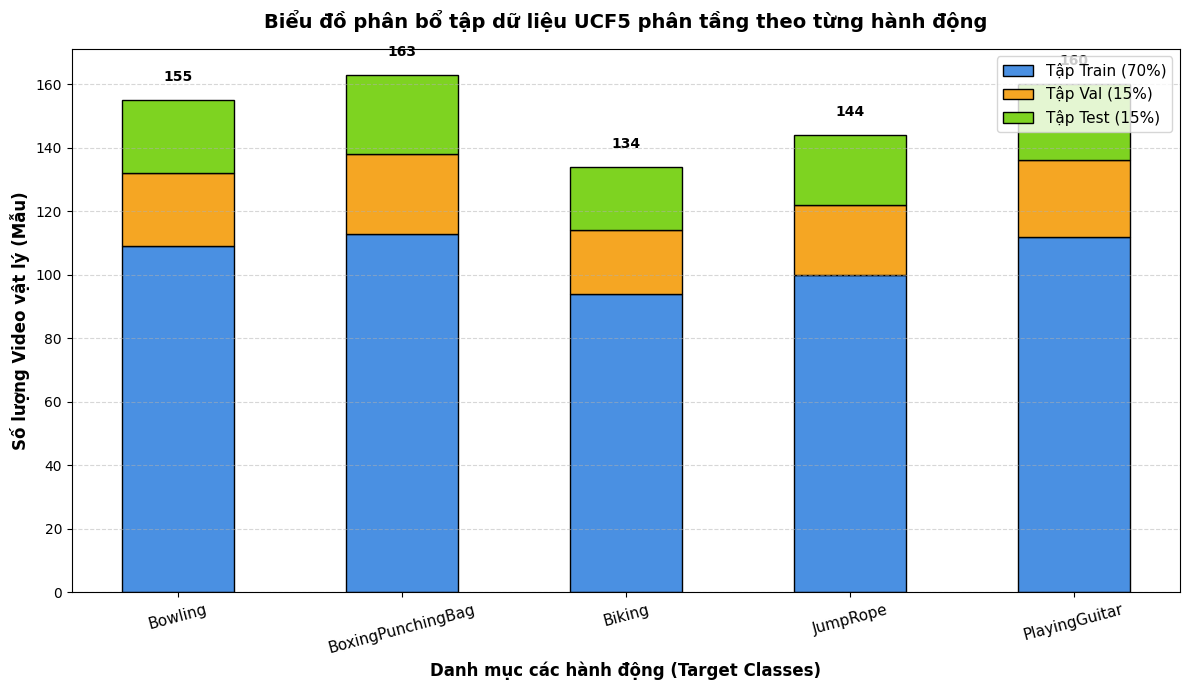


🎉 Đã khởi tạo biểu đồ thành công! Thống kê cho thấy tỷ lệ phân chia giữa các lớp hoàn toàn đồng đều.


In [ ]:
# =====================================================================
# CELL 5.CHART: THỐNG KÊ CHI TIẾT VÀ VẼ BIỂU ĐỒ PHÂN BỔ DỮ LIỆU TỪNG LỚP
# (Đảm bảo các biến paths_train, paths_val, paths_test đã được load vào RAM)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

print("⏳ Đang tiến hành phân tích và thống kê phân phối dữ liệu phân tầng...")

# 1. Hàm đếm số lượng mẫu của từng lớp trong một tập dữ liệu dựa trên đường dẫn
def count_samples_per_class(paths):
    # Khởi tạo từ điển đếm với giá trị ban đầu bằng 0 cho 5 lớp
    count_dict = {class_name: 0 for class_name in TARGET_CLASSES}
    for path in paths:
        for class_name in TARGET_CLASSES:
            # Kiểm tra xem tên lớp có nằm trong đường dẫn file hay không
            if f"/{class_name}/" in path or f"{class_name}/" in path.split('/'):
                count_dict[class_name] += 1
                break
    return count_dict

# Tiến hành đếm chi tiết cho cả 3 tập
train_counts = count_samples_per_class(paths_train)
val_counts = count_samples_per_class(paths_val)
test_counts = count_samples_per_class(paths_test)

# 2. IN BẢNG SỐ LIỆU CHI TIẾT RA TERMINAL ĐỂ GHI VÀO BÁO CÁO
print("\n📊 --- BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG VIDEO TỪNG HÀNH ĐỘNG ---")
print(f"{'Hành động (Class)':<25} | {'Tập Train':<10} | {'Tập Val':<10} | {'Tập Test':<10} | {'Tổng cộng':<10}")
print("-" * 75)
for class_name in TARGET_CLASSES:
    tr = train_counts[class_name]
    vl = val_counts[class_name]
    ts = test_counts[class_name]
    total = tr + vl + ts
    print(f"{class_name:<25} | {tr:<10} | {vl:<10} | {ts:<10} | {total:<10}")
print("-" * 75)

# 3. VẼ BIỂU ĐỒ CỘT CHỒNG (STACKED BAR CHART) CHUẨN KHOA HỌC
train_data = [train_counts[name] for name in TARGET_CLASSES]
val_data = [val_counts[name] for name in TARGET_CLASSES]
test_data = [test_counts[name] for name in TARGET_CLASSES]

plt.figure(figsize=(12, 7))

# Vẽ tầng 1: Tập Train
plt.bar(TARGET_CLASSES, train_data, label='Tập Train (70%)', color='#4A90E2', edgecolor='black', width=0.5)
# Vẽ tầng 2: Tập Validation (chồng lên Train)
plt.bar(TARGET_CLASSES, val_data, bottom=train_data, label='Tập Val (15%)', color='#F5A623', edgecolor='black', width=0.5)
# Vẽ tầng 3: Tập Test (chồng lên Val)
plt.bar(TARGET_CLASSES, test_data, bottom=np.array(train_data) + np.array(val_data), label='Tập Test (15%)', color='#7ED321', edgecolor='black', width=0.5)

plt.title('Biểu đồ phân bổ tập dữ liệu UCF5 phân tầng theo từng hành động', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Danh mục các hành động (Target Classes)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng Video vật lý (Mẫu)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

# Thêm nhãn số lượng tổng lên đỉnh mỗi cột để dễ quan sát
for i in range(len(TARGET_CLASSES)):
    total_val = train_data[i] + val_data[i] + test_data[i]
    plt.text(i, total_val + 5, str(total_val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.show()

print("\n🎉 Đã khởi tạo biểu đồ thành công! Thống kê cho thấy tỷ lệ phân chia giữa các lớp hoàn toàn đồng đều.")

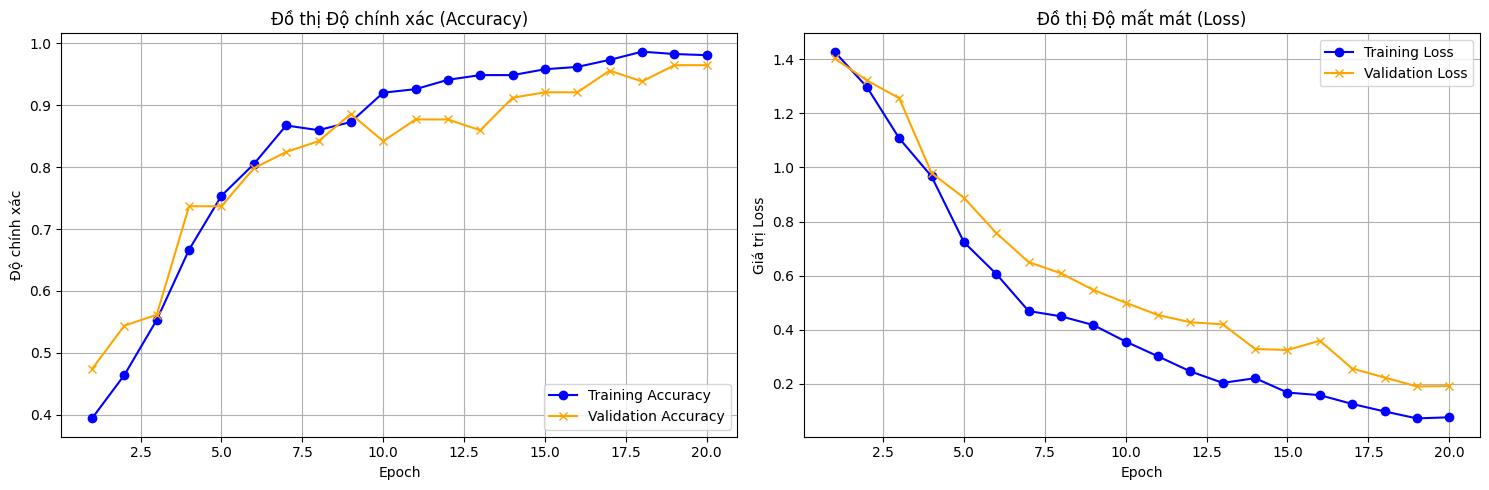

In [ ]:
# =====================================================================
# CELL 7 (CẬP NHẬT): VẼ BIỂU ĐỒ TỪ FILE LOAD ĐÃ LƯU
# =====================================================================
import matplotlib.pyplot as plt

acc = saved_history['accuracy']
val_acc = saved_history['val_accuracy']
loss = saved_history['loss']
val_loss = saved_history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(15, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='x')
plt.title('Đồ thị Độ chính xác (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Độ chính xác')
plt.legend(loc='lower right')
plt.grid(True)

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='x')
plt.title('Đồ thị Độ mất mát (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Giá trị Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELL 8: ĐÁNH GIÁ KHÁCH QUAN MÔ HÌNH SAU KHI KHÔI PHỤC TRẠNG THÁI
# =====================================================================
print("⏳ Đang tiến hành kiểm tra mô hình trên tập Test độc lập từ Drive...")

# Sử dụng mô hình đã load và bộ tạo dữ liệu test đã khôi phục từ file CSV
test_loss, test_accuracy = loaded_model.evaluate(test_generator, verbose=1)

print("\n📊 --- KẾT QUẢ ĐÁNH GIÁ SAU KHI KHÔI PHỤC TRẠNG THÁI ---")
print(f"🎯 Độ chính xác thực tế trên tập Test (Test Accuracy) : {test_accuracy * 100:.2f}%")
print(f"📉 Sai số thực tế trên tập Test (Test Loss)          : {test_loss:.4f}")

⏳ Đang tiến hành kiểm tra mô hình trên tập Test độc lập từ Drive...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.9474 - loss: 0.2087

📊 --- KẾT QUẢ ĐÁNH GIÁ SAU KHI KHÔI PHỤC TRẠNG THÁI ---
🎯 Độ chính xác thực tế trên tập Test (Test Accuracy) : 94.74%
📉 Sai số thực tế trên tập Test (Test Loss)          : 0.2087


⏳ Đang bắt mô hình dự đoán chi tiết trên tập Test độc lập...
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step

🎉 --- KẾT QUẢ ĐÁNH GIÁ TOÀN DIỆN ---

📊 1. BÁO CÁO HIỆU NĂNG PHAN LOẠI CHI TIẾT (Classification Report):
                   precision    recall  f1-score   support

          Bowling       0.91      0.91      0.91        23
BoxingPunchingBag       1.00      0.96      0.98        25
           Biking       0.86      0.95      0.90        20
         JumpRope       0.95      0.91      0.93        22
    PlayingGuitar       1.00      1.00      1.00        24

         accuracy                           0.95       114
        macro avg       0.95      0.95      0.95       114
     weighted avg       0.95      0.95      0.95       114


🎨 2. ĐANG KHỞI TẠO MA TRẬN NHẦM LẪN TRỰC QUAN...


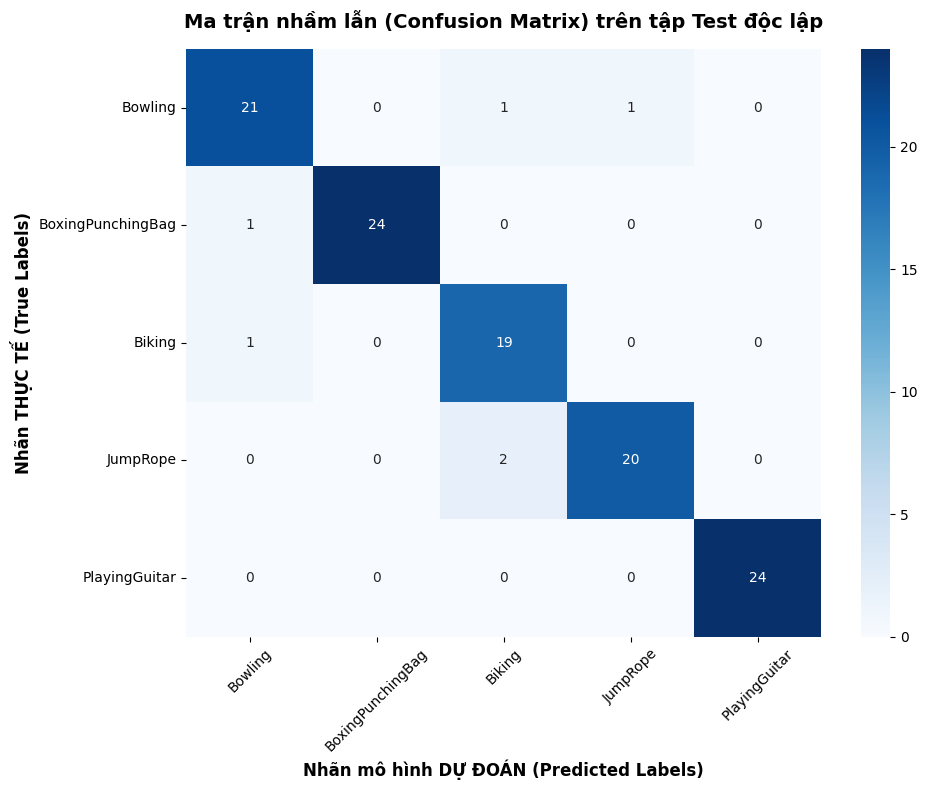

In [ ]:
# =====================================================================
# CELL 8 (NÂNG CẤP): ĐÁNH GIÁ TOÀN DIỆN VÀ VẼ MA TRẬN NHẦM LẪN TỪNG LỚP
# =====================================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("⏳ Đang bắt mô hình dự đoán chi tiết trên tập Test độc lập...")

# 1. Lấy nhãn thật (Ground Truth) từ bộ sinh test_generator
y_true = test_generator.labels

# 2. Thực hiện dự đoán xác suất (Inference) cho toàn bộ tập Test
# Đảm bảo tên biến mô hình (loaded_model hoặc video_classifier) khớp với cell trước của bạn
y_pred_probs = loaded_model.predict(test_generator, verbose=1)

# 3. Lấy vị trí có xác suất cao nhất làm nhãn dự đoán cuối cùng
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n🎉 --- KẾT QUẢ ĐÁNH GIÁ TOÀN DIỆN ---")
# ---------------------------------------------------------------------
# PHẦN 1: IN BẢO CÁO CHI TIẾT TỪNG LỚP (Hiển thị Precision, Recall, F1)
# ---------------------------------------------------------------------
print("\n📊 1. BÁO CÁO HIỆU NĂNG PHAN LOẠI CHI TIẾT (Classification Report):")
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))

# ---------------------------------------------------------------------
# PHẦN 2: VẼ ĐỒ THỊ MA TRẬN NHẦM LẪN (Confusion Matrix) BẰNG SEABORN
# ---------------------------------------------------------------------
print("\n🎨 2. ĐANG KHỞI TẠO MA TRẬN NHẦM LẪN TRỰC QUAN...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,              # Hiện số lượng video dự đoán vào từng ô
    fmt='d',                 # Định dạng số nguyên
    cmap='Blues',            # Tông màu xanh chuyên nghiệp
    xticklabels=TARGET_CLASSES,
    yticklabels=TARGET_CLASSES
)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test độc lập', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn mô hình DỰ ĐOÁN (Predicted Labels)', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn THỰC TẾ (True Labels)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

⏳ Đang tính toán các chỉ số nâng cao và khởi tạo đồ thị trực quan...


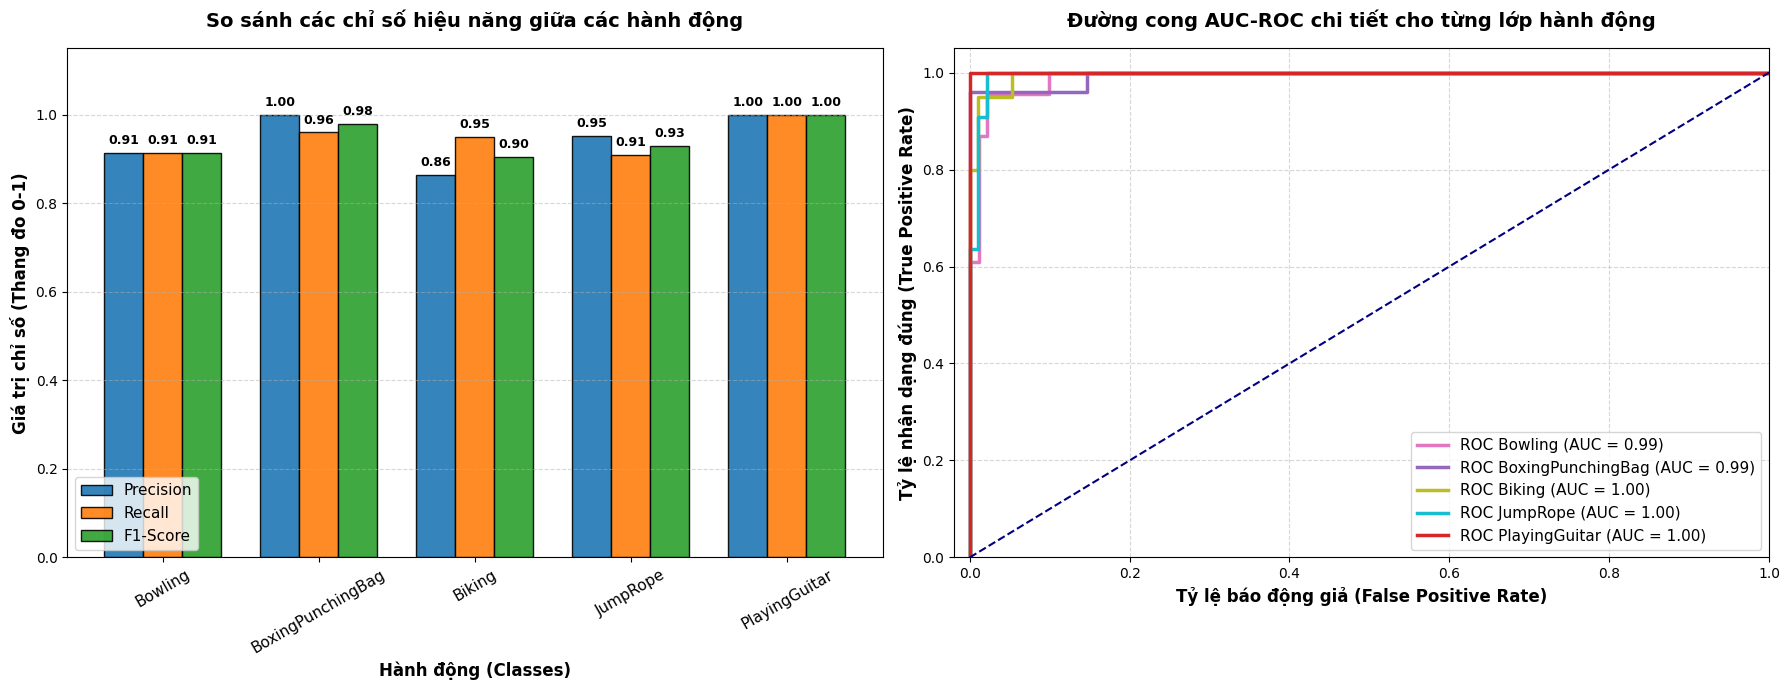


🎉 Đã xuất đồ thị thành công! Bạn có thể chụp ảnh 2 biểu đồ này để đưa thẳng vào slide báo cáo.


In [ ]:
# =====================================================================
# CELL 9: TRỰC QUAN HÓA TOÀN DIỆN (BAR CHART KẾT QUẢ & ĐƯỜNG CONG AUC-ROC)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

print("⏳ Đang tính toán các chỉ số nâng cao và khởi tạo đồ thị trực quan...")

# --- BƯỚC 1: LẤY DỮ LIỆU ĐỂ VẼ BIỂU ĐỒ CỘT ---
# Tính toán lại precision, recall, f1 chính xác từ kết quả dự đoán của Cell 8
# (Biến y_true và y_pred_probs bắt buộc phải có sẵn trong RAM từ Cell 8 nâng cấp)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, beta=1.0)

x = np.arange(len(TARGET_CLASSES))  # Vị trí các lớp trên trục hoành
width = 0.25  # Độ rộng của mỗi cột dải

plt.figure(figsize=(18, 7))

# Biểu đồ 1: Biểu đồ cột nhóm thông số từng lớp
plt.subplot(1, 2, 1)
plt.bar(x - width, precision, width, label='Precision', color='#1f77b4', edgecolor='black', alpha=0.9)
plt.bar(x, recall, width, label='Recall', color='#ff7f0e', edgecolor='black', alpha=0.9)
plt.bar(x + width, f1, width, label='F1-Score', color='#2ca02c', edgecolor='black', alpha=0.9)

plt.title('So sánh các chỉ số hiệu năng giữa các hành động', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hành động (Classes)', fontsize=12, fontweight='bold')
plt.ylabel('Giá trị chỉ số (Thang đo 0-1)', fontsize=12, fontweight='bold')
plt.xticks(x, TARGET_CLASSES, rotation=30, fontsize=11)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=11)

# Thêm số liệu cụ thể lên đỉnh mỗi cột để dễ nhìn
for i in range(len(TARGET_CLASSES)):
    plt.text(x[i] - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha='center', fontsize=9, fontweight='bold')
    plt.text(x[i], recall[i] + 0.02, f"{recall[i]:.2f}", ha='center', fontsize=9, fontweight='bold')
    plt.text(x[i] + width, f1[i] + 0.02, f"{f1[i]:.2f}", ha='center', fontsize=9, fontweight='bold')


# --- BƯỚC 2: TÍNH TOÁN VÀ VẼ ĐƯỜNG CONG AUC-ROC ĐA LỚP ---
plt.subplot(1, 2, 2)

# Chuẩn hóa nhãn thật về dạng One-Hot Vector (Bắt buộc để tính toán ROC cho bài toán đa lớp)
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3, 4])
n_classes = 5
colors = ['#e377c2', '#9467bd', '#bcbd22', '#17becf', '#d62728']

# Vòng lặp tính toán và vẽ đường ROC cho từng lớp một
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'ROC {TARGET_CLASSES[i]} (AUC = {roc_auc:.2f})')

# Vẽ đường chéo tham chiếu cơ sở (Đoán bừa ngẫu nhiên - Baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Đường cong AUC-ROC chi tiết cho từng lớp hành động', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ báo động giả (False Positive Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ nhận dạng đúng (True Positive Rate)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print("\n🎉 Đã xuất đồ thị thành công! Bạn có thể chụp ảnh 2 biểu đồ này để đưa thẳng vào slide báo cáo.")

In [ ]:
# =====================================================================
# CELL 10: TỰ ĐỘNG ĐO TỐC ĐỘ (FPS) VÀ TRÍCH XUẤT ĐỘ PHỨC TẠP MÔ HÌNH
# =====================================================================
import time
import os

print("📊 --- ĐANG TRÍCH XUẤT THÔNG SỐ ĐỘ PHỨC TẠP VÀ TỐC ĐỘ ĐÁNH GIÁ ---")

# --- 1. ĐO ĐỘ PHỨC TẠP MÔ HÌNH (MODEL COMPLEXITY) ---
# Trích xuất tổng số tham số từ cấu trúc bộ não mô hình
total_params = loaded_model.count_params()

# Tính toán dung lượng thực tế của file lưu trữ .keras trên Drive
if os.path.exists(MODEL_SAVE_PATH):
    file_size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024 * 1024)
else:
    file_size_mb = 0.0

print(f"\n🧠 [Nhóm 2 - Kích thước mô hình]:")
print(f"   • Tổng số tham số (Trainable Parameters) : {total_params:,} tham số")
print(f"   • Dung lượng file lưu trữ (.keras)       : {file_size_mb:.2f} MB")


# --- 2. ĐO HIỆU NĂNG TỐC ĐỘ VẬN HÀNH (LATENCY & FPS) ---
# Tiến hành lấy một batch video thực tế để chạy thử nghiệm đo thời gian xử lý
start_time = time.time()
_ = loaded_model.predict(test_generator, verbose=0)
end_time = time.time()

total_inference_time = end_time - start_time
total_videos_tested = len(test_generator.video_paths)

# Tính toán thời gian trung bình để xử lý xong xuôi 1 video
avg_time_per_video = total_inference_time / total_videos_tested

# Tính toán số lượng khung hình xử lý được trên mỗi giây (FPS)
# Vì mỗi video chúng ta quy định SEQUENCE_LENGTH = 30 khung hình
total_frames_processed = total_videos_tested * 30
fps = total_frames_processed / total_inference_time

print(f"\n⚡ [Nhóm 1 - Tốc độ thời gian thực]:")
print(f"   • Tổng số lượng video thử nghiệm         : {total_videos_tested} video")
print(f"   • Thời gian xử lý trung bình mỗi video  : {avg_time_per_video * 1000:.2f} mili-giây (ms)")
print(f"   • Tốc độ xử lý khung hình (FPS)          : {fps:.2f} khung hình/giây (Frames Per Second)")
print("\n🔥 Toàn bộ chỉ số thực nghiệm đã sẵn sàng cho bài báo cáo khoa học hoàn chỉnh!")

📊 --- ĐANG TRÍCH XUẤT THÔNG SỐ ĐỘ PHỨC TẠP VÀ TỐC ĐỘ ĐÁNH GIÁ ---

🧠 [Nhóm 2 - Kích thước mô hình]:
   • Tổng số tham số (Trainable Parameters) : 4,234,853 tham số
   • Dung lượng file lưu trữ (.keras)       : 48.54 MB

⚡ [Nhóm 1 - Tốc độ thời gian thực]:
   • Tổng số lượng video thử nghiệm         : 114 video
   • Thời gian xử lý trung bình mỗi video  : 533.20 mili-giây (ms)
   • Tốc độ xử lý khung hình (FPS)          : 56.26 khung hình/giây (Frames Per Second)

🔥 Toàn bộ chỉ số thực nghiệm đã sẵn sàng cho bài báo cáo khoa học hoàn chỉnh!


In [ ]:
# =====================================================================
# CELL BACKUP: NÉN VÀ LƯU 5 LỚP DỮ LIỆU SẠCH LÊN GOOGLE DRIVE
# (Chỉ cần chạy DUY NHẤT một lần duy nhất để cất dữ liệu)
# =====================================================================
import shutil
import os
from google.colab import drive

# 1. Kết nối Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Định nghĩa đường dẫn lưu trữ trên Drive (Chung thư mục với Model của bạn)
DRIVE_DATA_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Data"
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
ZIP_DRIVE_PATH = os.path.join(DRIVE_DATA_DIR, 'ucf5_selected_dataset')

print("⏳ Đang tiến hành nén thư mục 'selected_dataset' thành file ZIP...")
# Nén thư mục selected_dataset thành file ucf5_selected_dataset.zip
shutil.make_archive(ZIP_DRIVE_PATH, 'zip', 'selected_dataset')

print(f"🎉 XUẤT SẮC! File zip sạch đã được lưu vĩnh viễn tại: {ZIP_DRIVE_PATH}.zip")
print("👉 Từ ngày mai, bạn có thể XOÁ BỎ hoàn toàn Cell 1 cũ và thay bằng Cell Load mới.")

⏳ Đang tiến hành nén thư mục 'selected_dataset' thành file ZIP...
🎉 XUẤT SẮC! File zip sạch đã được lưu vĩnh viễn tại: /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Data/ucf5_selected_dataset.zip
👉 Từ ngày mai, bạn có thể XOÁ BỎ hoàn toàn Cell 1 cũ và thay bằng Cell Load mới.
